In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import seaborn as sns

In [6]:
# Set the default template globally
pio.templates.default = "plotly_white"

#Reads the dataframe from memory
df = pd.read_csv('../data/processed/rail_accident_pop.xls', low_memory = False)
#Display all columns
pd.set_option('display.max_columns', None)

In [7]:
df['Date'] = pd.to_datetime(df.loc[:, 'Date'])
df['Time'] = pd.to_datetime(df.loc[:, 'Time'])
df['Hour'] = df['Time'].dt.hour
df['Persons Evacuated'] = df['Persons Evacuated'].str.replace(',', '').astype(int)
df['Gross Tonnage'] = df['Gross Tonnage'].str.replace(',', '').astype(int)
df['Equipment Damage Cost'] = df.loc[:, 'Equipment Damage Cost'].str.replace(',', '').astype(float)
df['Track Damage Cost'] = df.loc[:, 'Track Damage Cost'].str.replace(',', '').astype(float)
df['Total Damage Cost'] = df.loc[:, 'Total Damage Cost'].str.replace(',', '').astype(float)

C:\Users\Timothy Mai\AppData\Local\Temp\ipykernel_14764\2896567986.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df.loc[:, 'Time'])


In [8]:
features = [
            'Reporting Railroad Code', 'Accident Month', 'Hour', 
            'Accident Type Code', 'Hazmat Cars', 'Hazmat Cars Damaged', 'Hazmat Released Cars', 'Persons Evacuated', 'State Code', 
            'Temperature', 'Visibility Code', 'Weather Condition Code', 'Track Type Code', 'Track Class', 'Train Direction Code', 
            'Equipment Type Code', 'Train Speed', 'Maximum Speed', 'Gross Tonnage', 'Signalization Code', 'Causing Car Position',
            'Head End Locomotives', 'Mid Train Manual Locomotives', 'Mid Train Remote Locomotives', 'Rear End Manual Locomotives', 
            'Rear End Remote Locomotives', 'Derailed Head End Locomotives', 'Derailed Mid Train Manual Locomotives',
            'Derailed Mid Train Remote Locomotives', 'Derailed Rear End Manual Locomotives', 'Derailed Rear End Remote Locomotives',
            'Derailed Mid Train Remote Locomotives', 'Derailed Rear End Manual Locomotives', 'Derailed Rear End Remote Locomotives',
            'Loaded Freight Cars', 'Loaded Passenger Cars', 'Empty Freight Cars', 'Empty Passenger Cars', 'Cabooses',
            'Derailed Loaded Freight Cars', 'Derailed Loaded Passenger Cars', 'Derailed Empty Freight Cars', 
            'Derailed Empty Passenger Cars', 'Derailed Cabooses', 'Accident Cause Code', 
            'Engineers On Duty', 'Firemen On Duty', 'Conductors On Duty', 'Brakemen On Duty',
            'Railroad Employees Killed', 'Railroad Employees Injured', 'Passengers Killed', 'Passengers Injured', 
            'Others Killed', 'Others Injured', 'Total Persons Killed', 'Total Persons Injured',
            'Joint Track Class', 'Class Code', 'Class', 'FIPS', 'Population_2020', 'RUCC_2023', 'Location_Class', 'Cause_Category'
           ]

#targets = ['Equipment Damage Cost', 'Track Damage Cost', 'Total Damage Cost']
targets = ['Total Damage Cost']
#Consider adding: Equipment Attended (bool), Passengers Transported (bool), Hours/Minutes Conductors/Engineers On Duty

corr_df = df[features + targets]
corr_df = corr_df.dropna()

#Factorizes all non-numeric columns
corr_df.loc[:, list(corr_df.dtypes == 'object')] = corr_df.loc[:, list(corr_df.dtypes == 'object')].apply(lambda x: pd.factorize(x)[0])


In [9]:
factor_keys = df.loc[:, list(df.dtypes == 'object')].apply(lambda x: pd.factorize(x)[1])
cause_categories = factor_keys['Cause_Category']

In [10]:
pd.set_option('display.max_rows', None)

corr_features = {}

for i in range(5):
    print(cause_categories[i])
    corr_features[cause_categories[i]] = corr_df[corr_df['Cause_Category'] == i].corr()['Total Damage Cost'].nlargest(6)
    display(corr_features[cause_categories[i]][1:])
    print()

pd.reset_option('display.max_rows')

T


Derailed Loaded Freight Cars    0.544316
Passengers Killed               0.473038
Passengers Injured              0.452416
Maximum Speed                   0.435206
Train Speed                     0.425841
Name: Total Damage Cost, dtype: float64


M


Derailed Loaded Freight Cars     0.285816
Persons Evacuated                0.208663
Hazmat Cars Damaged              0.125866
Derailed Head End Locomotives    0.120037
Derailed Empty Freight Cars      0.112559
Name: Total Damage Cost, dtype: float64


H


Total Persons Killed              0.686923
Total Persons Injured             0.619981
Passengers Injured                0.548166
Passengers Killed                 0.525057
Derailed Loaded Passenger Cars    0.522602
Name: Total Damage Cost, dtype: float64


E


Derailed Loaded Freight Cars    0.665806
Hazmat Released Cars            0.384632
Hazmat Cars Damaged             0.329969
Loaded Freight Cars             0.276738
Gross Tonnage                   0.262204
Name: Total Damage Cost, dtype: float64


S


Total Persons Injured             0.593153
Passengers Injured                0.526532
Derailed Loaded Passenger Cars    0.492655
Maximum Speed                     0.478226
Train Speed                       0.393806
Name: Total Damage Cost, dtype: float64

| Code | Category | Examples |
|------|----------|----------|
| H | Human Factors | Operator error, procedure violations, switching mistakes |
| M | Mechanical & Electrical | Equipment failures, brake defects, mechanical breakdowns |
| T | Track | Track geometry defects, rail defects, track maintenance issues |
| S | Signal | Signal system failures, communication errors |
| E | Miscellaneous/Environmental | Weather, vandalism, other external factors |

| Cause Category | Code / Category | 
|---|----|
| 0 | Track (T) |
| 1 | Mechanical (M) |
| 2 | Human Factors (H) |
| 3 | Miscellaneous/Environmental (E) |
| 4 | Signal (S) |

In [11]:
# Checking avg value of each feature with Total Damage Cost

corr_df.groupby("Cause_Category")[[
    "Train Speed",
    "Maximum Speed",
    "Gross Tonnage",
    "Derailed Loaded Freight Cars",
    "Passengers Injured",
    "Hazmat Released Cars",
    "Total Damage Cost"
]].mean()

,Train Speed,Maximum Speed,Gross Tonnage,Derailed Loaded Freight Cars,Passengers Injured,Hazmat Released Cars,Total Damage Cost
Cause_Category,,,,,,,
0,10.467398,10.648970,4939.437096,3.996242,0.019540,0.038930,215919.012626
1,24.299889,24.759615,3275.823439,1.045290,0.164855,0.014075,171634.663880
2,5.797790,6.968581,2621.477332,0.977413,0.065080,0.007150,127342.159409
3,17.683638,18.211957,5998.282589,2.008690,0.002997,0.021876,215187.259215
4,5.671916,6.553806,1385.834646,0.709974,0.013123,0.003937,83655.653543


In [85]:
import matplotlib.pyplot as plt

# function for bar graphs
def compare_features(df, feature, target):
    
    grouped = (
        df.groupby(feature)[target]
        .mean()
    )
    
    plt.figure(figsize=(10,6))
    grouped.plot(kind='bar')
    
    plt.xlabel(feature)
    plt.ylabel(f"Average {target}")
    plt.title(f"{target} by {' & '.join(feature)}")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [88]:
[df_col for df_col in df.columns if "cost" in df_col.lower()]

['Equipment Damage Cost', 'Track Damage Cost', 'Total Damage Cost']

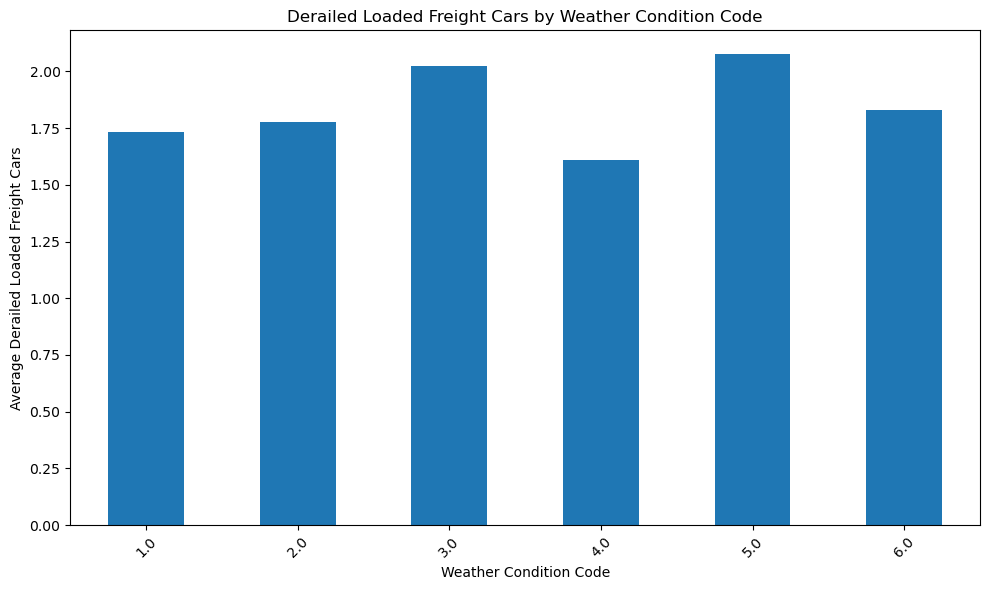

In [67]:
compare_features(corr_df, "Weather Condition Code", "Derailed Loaded Freight Cars")

## Comparing Weather Conditions

In [12]:
# Checking avg of weather condition codes vs number of derailed

corr_df.groupby("Weather Condition Code")["Derailed Loaded Freight Cars"].mean().sort_values(ascending=False)

Weather Condition Code
5.0    2.076923
3.0    2.024379
6.0    1.827526
2.0    1.777645
1.0    1.733128
4.0    1.608844
Name: Derailed Loaded Freight Cars, dtype: float64

| Weather Condition Code | Value | 
|---|----|
| 1 | clear |
| 2 | cloudy |
| 3 | rain |
| 4 | fog |
| 5 | sleet |
| 6 | snow |

In [68]:
# Comparing Weather Condition Code to Total Cost

corr_df.groupby("Weather Condition Code")["Total Damage Cost"].mean().sort_values(ascending=False)

Weather Condition Code
3.0    227635.781060
1.0    163060.682830
2.0    157801.005828
6.0    148266.322300
5.0    144820.400000
4.0    143149.724490
Name: Total Damage Cost, dtype: float64

In [15]:
corr_df.groupby("Weather Condition Code")["Total Persons Injured"].mean()

Weather Condition Code
1.0    0.201192
2.0    0.205320
3.0    0.112986
4.0    0.125850
5.0    0.046154
6.0    0.067944
Name: Total Persons Injured, dtype: float64

In [16]:
corr_df.groupby("Weather Condition Code")["Train Speed"].mean()

Weather Condition Code
1.0    12.648779
2.0    11.912044
3.0    12.968917
4.0    12.816327
5.0    13.261538
6.0    13.375087
Name: Train Speed, dtype: float64

In [17]:
# (Subjective) At least 3 is considered "bad weather" 

corr_df["Bad_Weather"] = corr_df["Weather Condition Code"].isin([3, 4, 5, 6])
corr_df.groupby("Bad_Weather")["Derailed Loaded Freight Cars"].mean()

Bad_Weather
False    1.744093
True     1.948793
Name: Derailed Loaded Freight Cars, dtype: float64

## Comparing Visibility / Speed

In [18]:
corr_df.groupby("Visibility Code")["Derailed Loaded Freight Cars"].mean().sort_values(ascending=False)

Visibility Code
1.0    1.857597
3.0    1.815442
4.0    1.759541
2.0    1.736215
Name: Derailed Loaded Freight Cars, dtype: float64

| Visibility Code | Value | 
|---|----|
| 1 | dawn |
| 2 | day |
| 3 | dusk |
| 4 | dark |

In [19]:
corr_df.groupby("Visibility Code")["Train Speed"].mean().sort_values(ascending=False)

Visibility Code
2.0    14.027891
1.0    11.824221
4.0    11.310703
3.0    10.848967
Name: Train Speed, dtype: float64

In [20]:
corr_df.groupby("Visibility Code")["Derailed Loaded Freight Cars"].mean()

Visibility Code
1.0    1.857597
2.0    1.736215
3.0    1.815442
4.0    1.759541
Name: Derailed Loaded Freight Cars, dtype: float64

In [21]:
corr_df.groupby("Visibility Code")["Total Damage Cost"].mean().sort_values(ascending=False)

Visibility Code
1.0    191894.427527
4.0    167396.701876
2.0    160323.565872
3.0    158509.905858
Name: Total Damage Cost, dtype: float64

## Crew Staffing 

In [22]:
corr_df["No_Brakemen"] = (corr_df["Brakemen On Duty"] == 0).astype(int)

corr_df.groupby("No_Brakemen")[[
    "Train Speed",
    "Derailed Loaded Freight Cars",
    "Total Persons Injured",
    "Total Damage Cost"
]].mean()


,Train Speed,Derailed Loaded Freight Cars,Total Persons Injured,Total Damage Cost
No_Brakemen,,,,
0,13.568682,1.313876,0.274868,109067.642519
1,12.200152,1.905239,0.166580,183642.327652


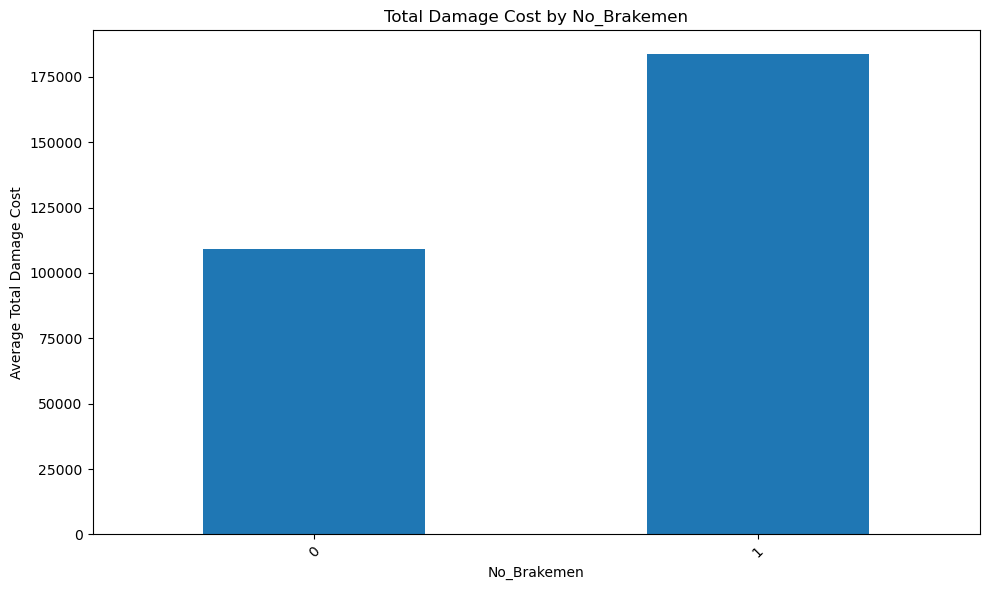

In [69]:
compare_features(corr_df, "No_Brakemen", "Total Damage Cost")

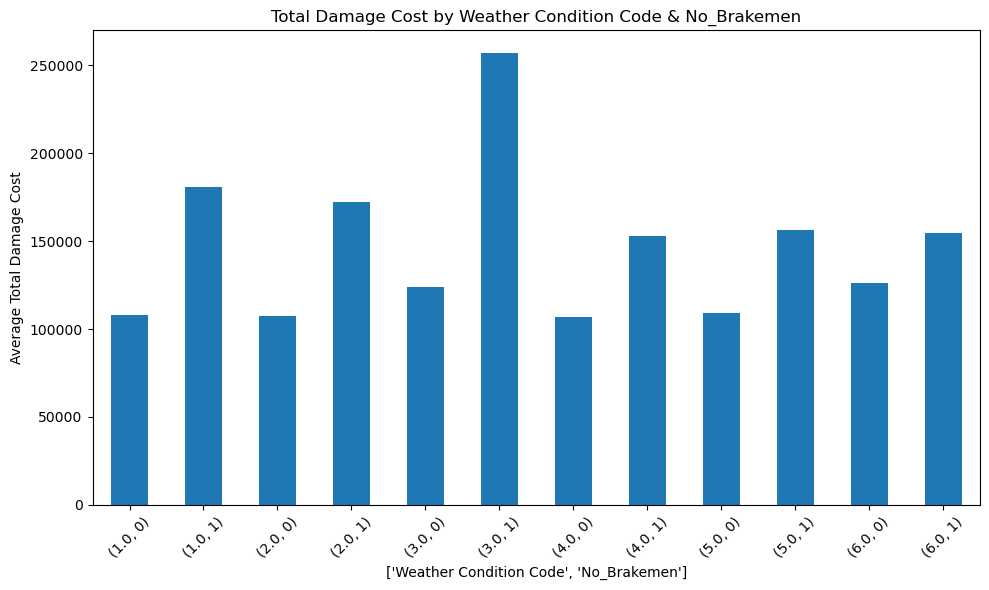

In [86]:
compare_features(corr_df, ["Weather Condition Code", "No_Brakemen"], "Total Damage Cost")

In [45]:
corr_df.groupby(["Weather Condition Code", "No_Brakemen"])["Derailed Loaded Freight Cars"].mean()

Weather Condition Code  No_Brakemen
1.0                     0              1.264121
                        1              1.885761
2.0                     0              1.456271
                        1              1.868507
3.0                     0              1.475584
                        1              2.179904
4.0                     0              1.459016
                        1              1.648069
5.0                     0              1.375000
                        1              2.306122
6.0                     0              0.952756
                        1              2.076063
Name: Derailed Loaded Freight Cars, dtype: float64

In [25]:
# Bad Weather / Brakemen vs Derailed

corr_df.groupby(["Bad_Weather", "No_Brakemen"])["Derailed Loaded Freight Cars"].mean()

Bad_Weather  No_Brakemen
False        0              1.307704
             1              1.881405
True         0              1.373333
             1              2.111251
Name: Derailed Loaded Freight Cars, dtype: float64

In [27]:
# Weather Code / Brakemen vs Total Damage Cost

corr_df.groupby(["Weather Condition Code", "No_Brakemen"])["Total Damage Cost"].mean()

Weather Condition Code  No_Brakemen
1.0                     0              107832.734686
                        1              181033.894693
2.0                     0              107156.225085
                        1              172119.781292
3.0                     0              123913.518047
                        1              257029.996390
4.0                     0              106652.704918
                        1              152704.738197
5.0                     0              108914.500000
                        1              156544.775510
6.0                     0              126278.755906
                        1              154513.348993
Name: Total Damage Cost, dtype: float64

In [29]:
# Bad Weather / Brakemen vs Total Damage Cost

corr_df.groupby(["Bad_Weather", "No_Brakemen"])["Total Damage Cost"].mean()

Bad_Weather  No_Brakemen
False        0              107679.289866
             1              178783.692457
True         0              122443.134815
             1              225638.736512
Name: Total Damage Cost, dtype: float64

In [30]:
# Visibility Code vs Brakemen

corr_df.groupby(["Visibility Code"])["No_Brakemen"].mean()

Visibility Code
1.0    0.772727
2.0    0.763711
3.0    0.750423
4.0    0.761594
Name: No_Brakemen, dtype: float64

In [31]:
# RUCC vs Brakemen

corr_df.groupby(["RUCC_2023"])["No_Brakemen"].mean()

RUCC_2023
1    0.720437
2    0.766737
3    0.809202
4    0.787107
5    0.788636
6    0.835240
7    0.779676
8    0.878049
9    0.841176
Name: No_Brakemen, dtype: float64

## Gross Tonnage

In [32]:
corr_df[["Gross Tonnage", "Derailed Loaded Freight Cars"]].corr()

,Gross Tonnage,Derailed Loaded Freight Cars
Gross Tonnage,1.000000,0.365967
Derailed Loaded Freight Cars,0.365967,1.000000


## Models

In [33]:
corr_df.columns

Index(['Reporting Railroad Code', 'Accident Month', 'Hour',
       'Accident Type Code', 'Hazmat Cars', 'Hazmat Cars Damaged',
       'Hazmat Released Cars', 'Persons Evacuated', 'State Code',
       'Temperature', 'Visibility Code', 'Weather Condition Code',
       'Track Type Code', 'Track Class', 'Train Direction Code',
       'Equipment Type Code', 'Train Speed', 'Maximum Speed', 'Gross Tonnage',
       'Signalization Code', 'Causing Car Position', 'Head End Locomotives',
       'Mid Train Manual Locomotives', 'Mid Train Remote Locomotives',
       'Rear End Manual Locomotives', 'Rear End Remote Locomotives',
       'Derailed Head End Locomotives',
       'Derailed Mid Train Manual Locomotives',
       'Derailed Mid Train Remote Locomotives',
       'Derailed Rear End Manual Locomotives',
       'Derailed Rear End Remote Locomotives',
       'Derailed Mid Train Remote Locomotives',
       'Derailed Rear End Manual Locomotives',
       'Derailed Rear End Remote Locomotives', 'Loaded

In [34]:
# Top Features

corr = corr_df.corr()["Total Damage Cost"].sort_values(ascending=False)
top_features = corr[corr > 0.2].index.tolist()
print(top_features)


['Total Damage Cost', 'Derailed Loaded Freight Cars', 'Passengers Injured', 'Passengers Killed', 'Total Persons Injured', 'Railroad Employees Injured', 'Derailed Loaded Passenger Cars']


In [35]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import root_mean_squared_error, r2_score

In [41]:
# plot function

def model_results(y_test, y_pred, name):
    
    # log scaling
    print("R2_log:", r2_score(y_test, y_pred))
    print("RMSE_log:", root_mean_squared_error(y_test, y_pred))
    
    # original
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred)
    print("\nR2:", r2_score(y_test_orig, y_pred_orig))
    print("RMSE:", root_mean_squared_error(y_test_orig, y_pred_orig))

    # Plot
    plt.figure(figsize=(8,6))
    plt.scatter(y_test_orig, y_pred_orig)
    
    # prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
    
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{name}")
    
    plt.show()

In [39]:

# Features correlated to Derailed Loaded Feight Cars

#feats = ['Gross Tonnage', 'Derailed Loaded Freight Cars', 
#        'Weather Condition Code', 'Visibility Code', 'Train Speed',
#        'No_Brakemen', 'Total Damage Cost', 'Bad_Weather'
#        ]


# Test features
feats = ['Total Damage Cost', 'Derailed Loaded Freight Cars', 
         'Passengers Injured', 'Passengers Killed', 
         'Total Persons Injured', 'Railroad Employees Injured', 
         'Derailed Loaded Passenger Cars', 'Hazmat Released Cars', 
         'No_Brakemen', 'Cause_Category'
        ]

model_df = corr_df[feats]

np.random.seed(521)

X = model_df.drop("Total Damage Cost", axis=1)
y = np.log1p(model_df["Total Damage Cost"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Random Forest Regressor

In [33]:
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Best Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best Estimator: RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5)


R2_log: 0.2646476310528867
RMSE_log: 1.1296582458386022

R2: 0.34635819659264977
RMSE: 429991.26299307676


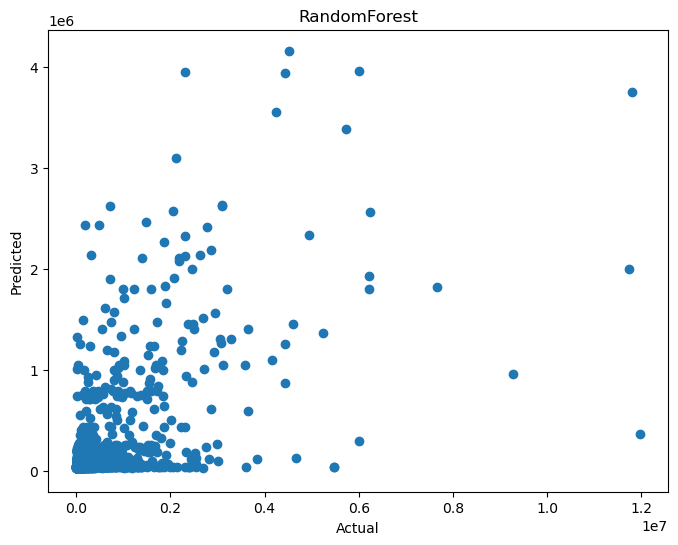

In [42]:
model = RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=400)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

model_results(y_test, y_pred, 'RandomForest')

### Decision Tree Regressor

R2_log: 0.24187590476702392
RMSE_log: 1.1470160073290219

R2: 0.20559993113013464
RMSE: 474033.8532350879


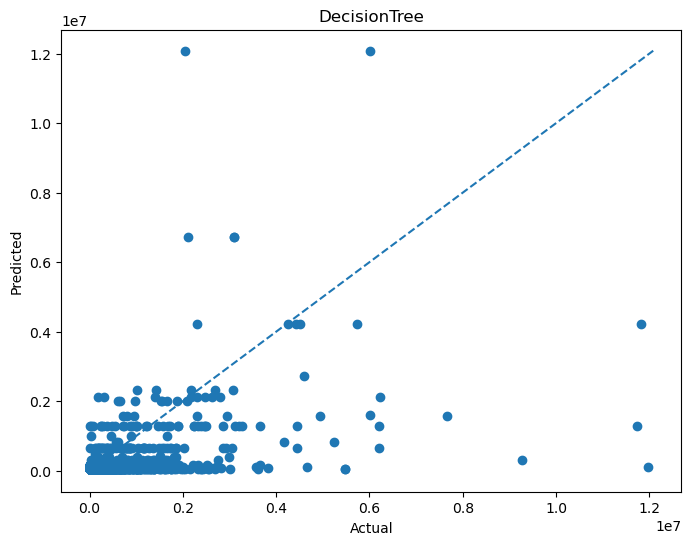

In [52]:
tree_model = DecisionTreeRegressor(max_depth=5, random_state=521)
tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

model_results(y_test, y_pred, 'DecisionTree')

### Gradient Boosting Regressor

R2_log: 0.2676539268996668
RMSE_log: 1.1273467247550344

R2: -7.169699493278685
RMSE: 1520172.117282442


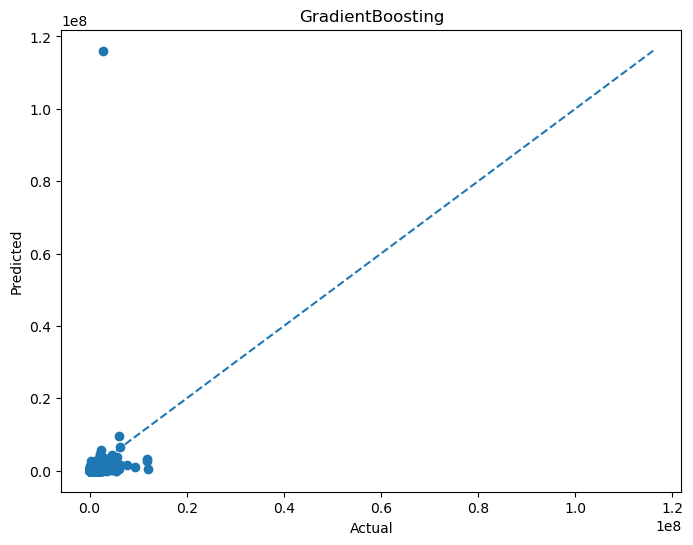

In [53]:
boost_model = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=3,
    random_state=521
)

boost_model.fit(X_train, y_train)

y_pred = boost_model.predict(X_test)

model_results(y_test, y_pred, 'GradientBoosting')

### Ada Boost Regressor

R2_log: 0.2099982382955462
RMSE_log: 1.1708826176469704

R2: 0.15937721540741479
RMSE: 487629.86925810843


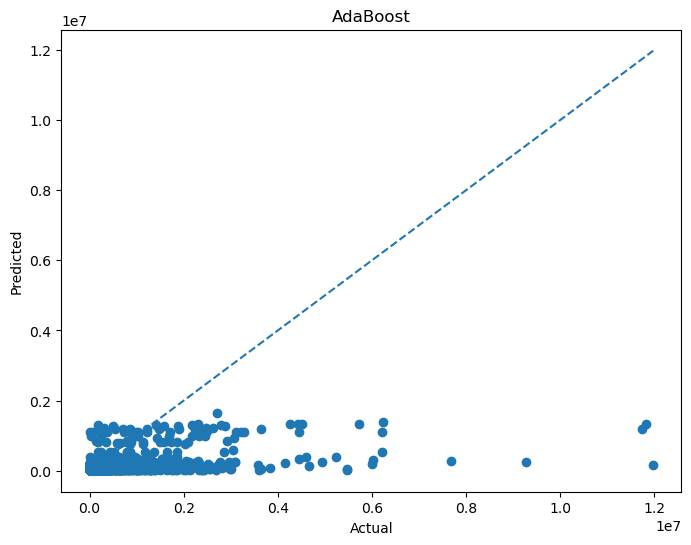

In [54]:
boost_model = AdaBoostRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=521
)

boost_model.fit(X_train, y_train)

y_pred = boost_model.predict(X_test)

model_results(y_test, y_pred, 'AdaBoost')

### Linear Regression

In [56]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

# Log scaling
print("R2_log:", r2_score(y_test, y_pred))
print("RMSE_log:", root_mean_squared_error(y_test, y_pred))

# original
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred)

print("\nR2:", r2_score(y_test_orig, y_pred_orig))
print("RMSE:", root_mean_squared_error(y_test_orig, y_pred_orig))

R2_log: 0.21882123054401226
RMSE_log: 1.1643258635533993

R2: -3592445.9473143704
RMSE: 1008056566.7556865
